Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9301 - loss: 0.2405 - val_accuracy: 0.9612 - val_loss: 0.1244
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9686 - loss: 0.1025 - val_accuracy: 0.9715 - val_loss: 0.0921
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9776 - loss: 0.0729 - val_accuracy: 0.9719 - val_loss: 0.0881
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9828 - loss: 0.0543 - val_accuracy: 0.9750 - val_loss: 0.0860
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9855 - loss: 0.0445 - val_accuracy: 0.9743 - val_loss: 0.0860
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0343 - val_accuracy: 0.9743 - val_loss: 0.0912
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9905 - loss: 0.0288 - val_accuracy: 0.9734 - val_loss: 0.0999
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9913 - loss: 0.0262 - 

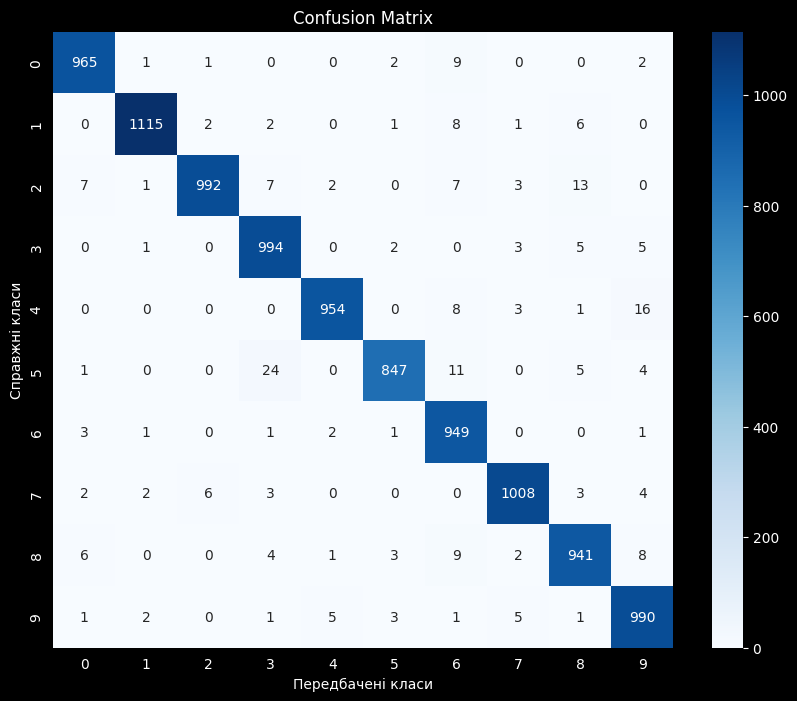

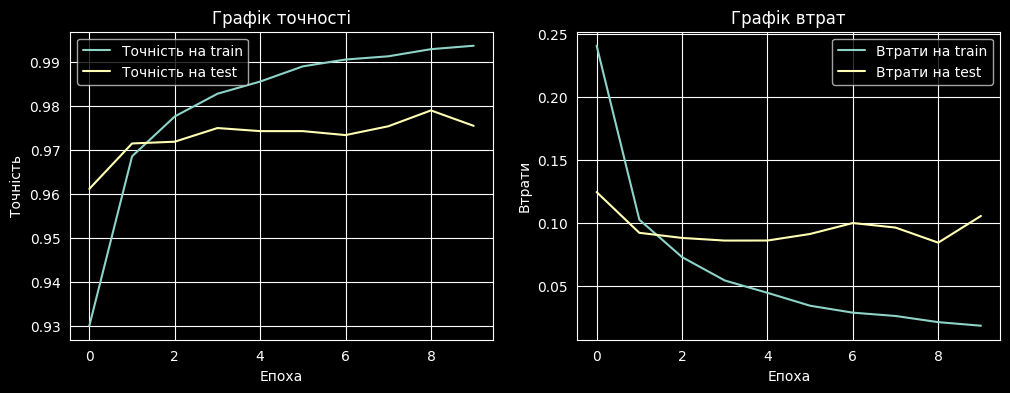

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


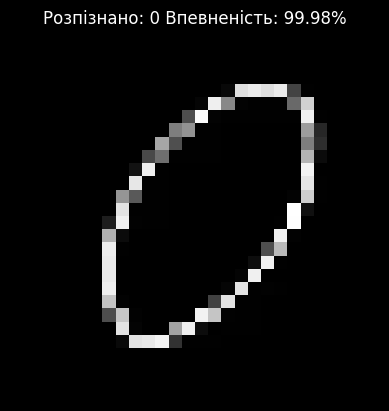

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


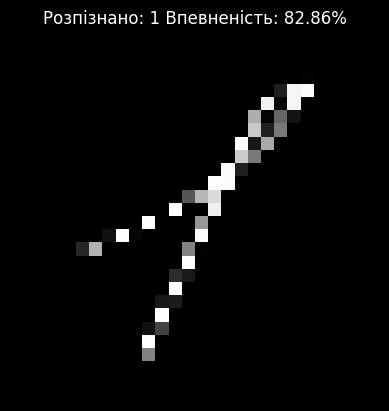

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


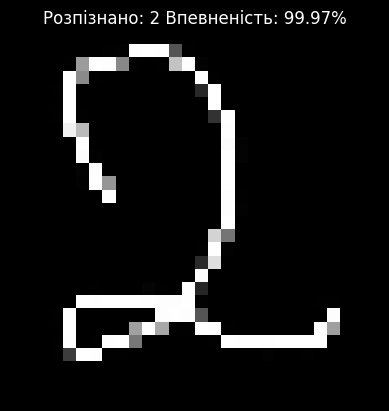

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


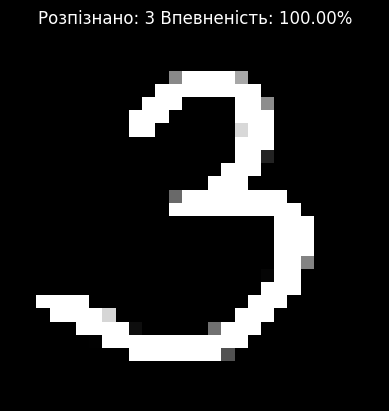

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


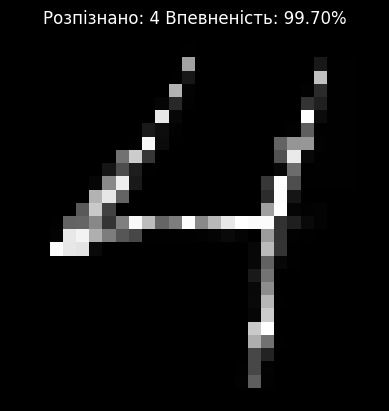

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


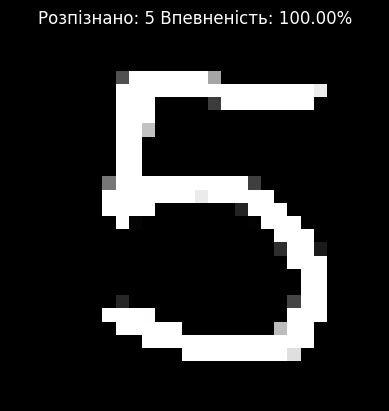

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


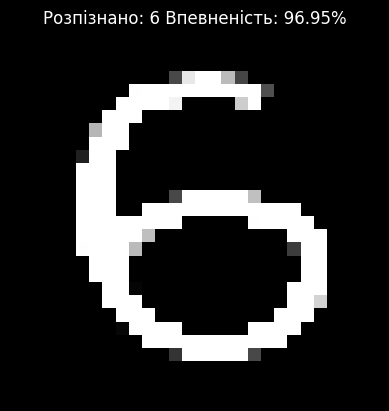

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


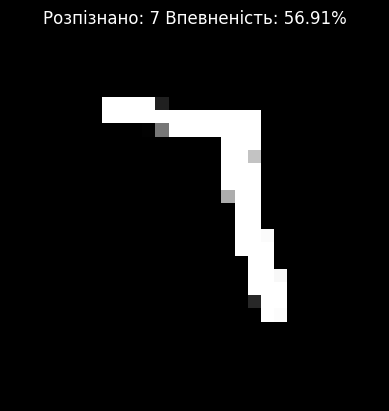

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


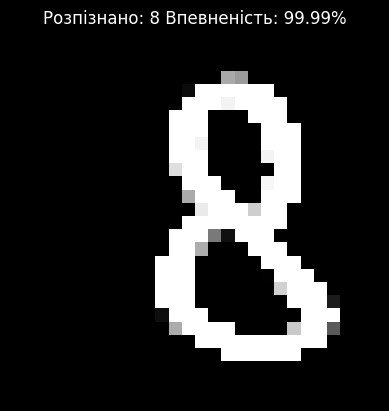

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


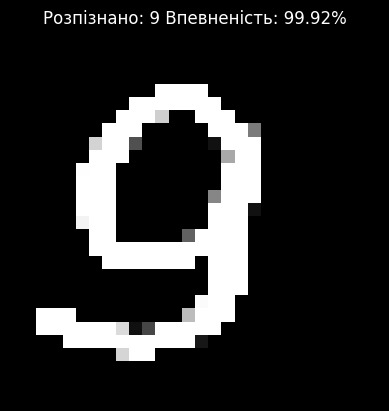

In [7]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import cv2

# завантаження датасету MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_test_original = x_test.copy()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# створення моделі
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# навчання моделі
history = model.fit(x_train, y_train_cat, epochs=10, batch_size=32, validation_data=(x_test, y_test_cat))

# тестування моделі
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f"Загальна точність на тестових даних: {accuracy * 100:.2f}%")

# оцінка правильності, матриця помилок та додаткові метрики
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nМетрики якості:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Передбачені класи')
plt.ylabel('Справжні класи')
plt.title('Confusion Matrix')
plt.show()

# візуалізація графіка навчання
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точність на train')
plt.plot(history.history['val_accuracy'], label='Точність на test')
plt.title('Графік точності')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Втрати на train')
plt.plot(history.history['val_loss'], label='Втрати на test')
plt.title('Графік втрат')
plt.xlabel('Епоха')
plt.ylabel('Втрати')
plt.legend()
plt.show()

# функція розпізнавання власноруч написаних цифр
def recognize_custom_digit(image_path, trained_model):
    try:
        # завантаження зображення у відтінках сірого
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Не вдалося завантажити зображення за шляхом '{image_path}'")
            return

        # інверсія зображення
        img = cv2.bitwise_not(img)

        img_resized = cv2.resize(img, (28, 28))
        img_normalized = img_resized.astype('float32') / 255.0
        img_flattened = img_normalized.reshape(1, 784)
        # передбачення моделі
        prediction_probs = trained_model.predict(img_flattened)
        predicted_digit = np.argmax(prediction_probs)
        confidence = np.max(prediction_probs) * 100
        plt.imshow(img_resized, cmap='gray')
        plt.title(f"Розпізнано: {predicted_digit} Впевненість: {confidence:.2f}%")
        plt.axis('off')
        plt.show()

        return predicted_digit

    except Exception as e:
        print(e)

for fn in ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']:
    recognize_custom_digit("lab3_imgs/" + fn + '.png', model)